**Лабараторная #1(Ecomon_Cities)**

Иерархический метод анализа и кластеризации данных

In [23]:
#подключаем бибилиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

In [21]:
#читаем данные
df = pd.read_csv('Econom_Cities_data.csv',sep=";",decimal=",")

#посмотрим данные
print(df.head(), '\n')
#и информацию про данные
print(df.info(), '\n')

#При детальном рассмотрении файла , можно заметить значения -9999 преобразуем их в пустые значения и выкинем такие строки
df = df.replace(-9999,np.nan)
df = df.dropna()

        City  Work  Price  Salary
0  Amsterdam  1714   65.6    49.0
1     Athens  1792   53.8    30.4
2     Bogota  2152   37.9    11.5
3     Bombay  2052   30.3     5.3
4   Brussels  1708   73.8    50.5 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   City    48 non-null     object 
 1   Work    48 non-null     int64  
 2   Price   48 non-null     float64
 3   Salary  48 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 1.6+ KB
None 



In [ ]:
#нормализуем данные

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['Work','Price','Salary']])

#Смотрим данные по тем столбцам , по которым масштабировали
X_scaled = pd.DataFrame(X_scaled, columns=['Work','Price','Salary'])

print("Нормализованные данные:")
print(X_scaled.head(), '\n')

Нормализованные данные:
       Work     Price    Salary
0 -0.962166 -0.212712  0.386095
1 -0.509827 -0.770489 -0.373488
2  1.577891 -1.522069 -1.145323
3  0.997969 -1.881316 -1.398517
4 -0.996961  0.174896  0.447351 



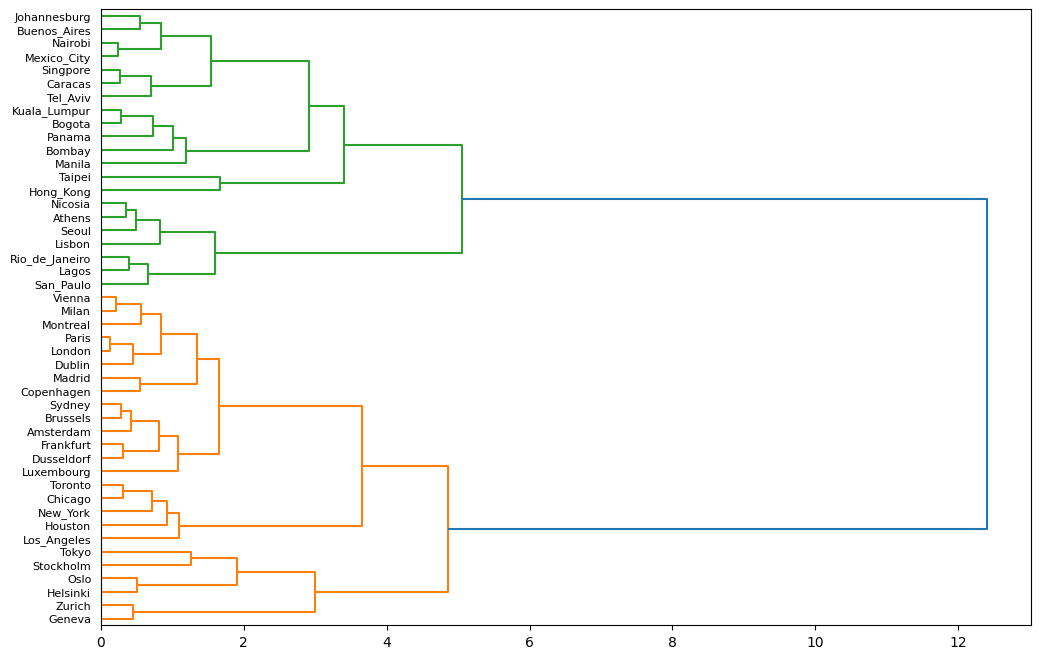

In [ ]:
# Используем linkage с методом Ward и евклидовой метрикой


link = linkage(X_scaled, method = 'ward',metric='euclidean')
labelList = df['City']

#посмтроим промежуточную дендограмму и выведем названия городов
plt.figure(figsize=(12, 8))
dendrogram(link, labels=labelList.values, orientation='right')
plt.show()

#на данном этапе уже можем заметить 2 кластера


In [ ]:
#определяем порог для разреза дендограммы

cut_height = 0.7 * np.max(link[:, 2])
print(f"Порог разреза: {cut_height:.2f}\n")

Порог разреза: 8.68



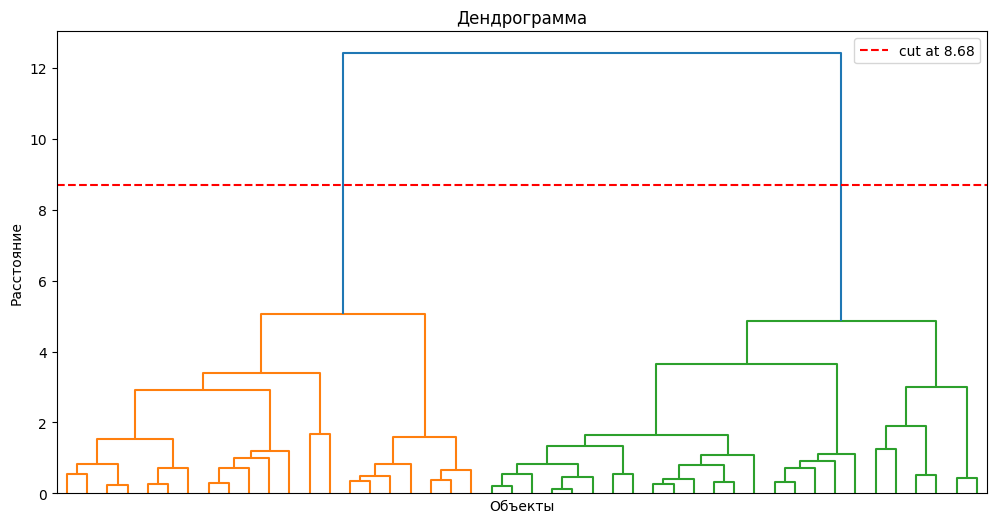

In [ ]:
#построим дендограмму

plt.figure(figsize=(12, 6))
dendrogram(link,
           no_labels=True,
           distance_sort='descending',
           show_leaf_counts=False)
plt.axhline(y=cut_height, color='red', linestyle='--', label=f'cut at {cut_height:.2f}')
plt.title("Дендрограмма")
plt.xlabel("Объекты")
plt.ylabel("Расстояние")
plt.legend()
plt.show()

Видим 2 явных кластера на дендограмме.
Построим график "Каменистый осыпи" для доп анализа

Выведем последние шаги объединения для болле крепного масштаба и наглядности графика

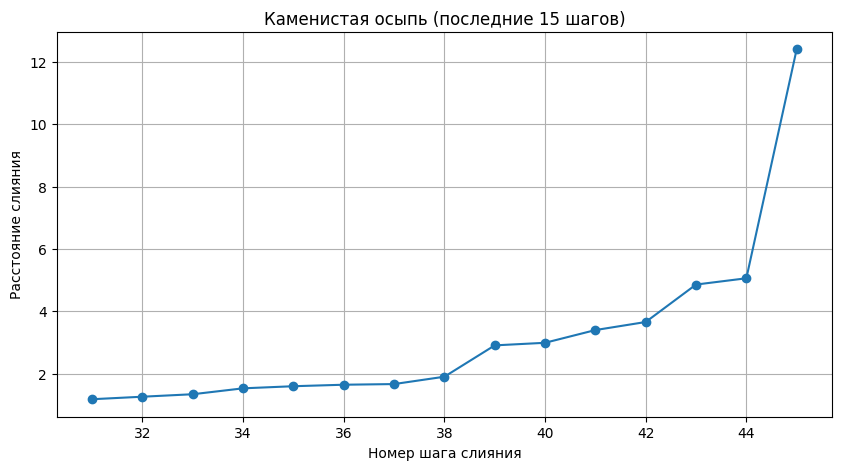

In [ ]:
distances = link[:, 2]
steps = np.arange(1, len(distances) + 1)
N_last = 15  # последние шаги объединений для наглядности

plt.figure(figsize=(10, 5))
plt.plot(steps[-N_last:], distances[-N_last:], marker='o', linestyle='-')
plt.title(f'Каменистая осыпь (последние {N_last} шагов)')
plt.xlabel('Номер шага слияния')
plt.ylabel('Расстояние слияния')
plt.grid(True)
plt.show()

Видим , что на 44 шаге излом начинается становится круче => расстояние становится больше , поэтому можно сделать вывод, что кластеров 2.

In [ ]:
#определяем кол-во класетров и разбиение

num_clusters = 2
df['cluster'] = fcluster(link, num_clusters, criterion='maxclust')

print("Размеры кластеров:")
print(df['cluster'].value_counts(), '\n')

Размеры кластеров:
cluster
1    25
2    21
Name: count, dtype: int64 



In [ ]:
#выведим среднии значения по кластерам и названия городов , которые попали в кластеры


print(df.groupby('cluster')[['Work','Salary','Price']].mean())
print(df.groupby('cluster')['City'].apply(list))

                Work     Salary      Price
cluster                                   
1        1789.240000  59.032000  84.972000
2        1987.857143  16.347619  52.395238
cluster
1    [Amsterdam, Brussels, Chicago, Copenhagen, Dub...
2    [Athens, Bogota, Bombay, Buenos_Aires, Caracas...
Name: City, dtype: object


**Интерпретация**

Можем разлечить два класетра:
1 - европейские экономически развитые города, характерищующиеся развитой инфраструктурой , высокими доходами и относительно высоким уровнем цен, а также менее интенсивным рабочим графиком , что может говорить о развитой социальной системе

2-в этот кластер входят города из развивающихся стран, для которых характерны более длительные рабочие дни и низкая оплата , а также низкая стоимость жизни

**Лабараторная #2(Ecomon_Cities)**

Кластерный анализ методом к-средних (k-means)

In [5]:
#возьмем код для подготовки датасета из прошлой лаборатоной https://colab.research.google.com/drive/1pDj3ABnJasQQD3JLb451StHf4iLz_o_g#scrollTo=_mBg90DcodFt&line=2&uniqifier=1
#нормализуем данные

X = df[['Work','Price','Salary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


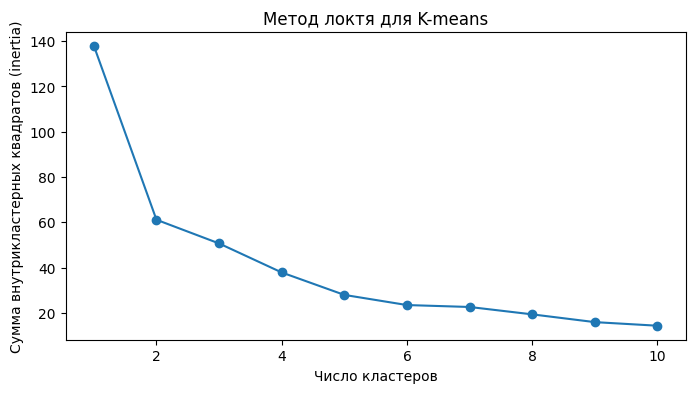

In [7]:
#построим график зависимости суммы внутрикластерных квадратов от количества кластеров

inertia = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, '-o')
plt.xlabel('Число кластеров')
plt.ylabel('Сумма внутрикластерных квадратов (inertia)')
plt.title('Метод локтя для K-means')
plt.show()

Видим локоть при числе кластеров = 2 , т.е уменьшее в этой точке стало меньше

In [19]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df['kmeans_cluster'] = labels

print(f'Сколько в каждом кластере:\n{df['kmeans_cluster'].value_counts()}\n')
print(f'Средние значения по кластерам:\n{df.groupby('kmeans_cluster')[['Work','Price','Salary']].mean()}\n')
print(f'Города по кластерам:\n{df.groupby('kmeans_cluster')['City'].apply(list)}\n')

Сколько в каждом кластере:
kmeans_cluster
1    25
0    21
Name: count, dtype: int64

Средние значения по кластерам:
                       Work      Price     Salary
kmeans_cluster                                   
0               1987.857143  52.395238  16.347619
1               1789.240000  84.972000  59.032000

Города по кластерам:
kmeans_cluster
0    [Athens, Bogota, Bombay, Buenos_Aires, Caracas...
1    [Amsterdam, Brussels, Chicago, Copenhagen, Dub...
Name: City, dtype: object



Можем наблюдать такое же четкое разделение на кластеры по экономическим признакам , как и при иерархическом анализе

**Лабараторная #3(Ecomon_Cities)**

Кластерный анализ методом DBSCAN

In [22]:
#как и до этого возьмем часть с подготовкой кода отсюда https://colab.research.google.com/drive/1pDj3ABnJasQQD3JLb451StHf4iLz_o_g#scrollTo=_mBg90DcodFt&line=3&uniqifier=1
# нормализуем

X = df[['Work', 'Price', 'Salary']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [43]:
#попробуем базовые параметры
dbscan = DBSCAN(eps=0.8, min_samples=3)
labels = dbscan.fit_predict(X_scaled)

df['dbscan_cluster'] = labels

In [46]:
print(f'Сколько в каждом кластере:\n{df['dbscan_cluster'].value_counts()}\n')
print(f'Средние значения по кластерам:\n{df.groupby('dbscan_cluster')[['Work','Price','Salary']].mean()}\n')
print(f'Города по кластерам:\n{df.groupby('dbscan_cluster')['City'].apply(list)}\n')
print(f'Какие города попали в выбросы:\n{df.query('dbscan_cluster == -1')['City']}\n')

Сколько в каждом кластере:
dbscan_cluster
 0    19
 1    19
-1     8
Name: count, dtype: int64

Средние значения по кластерам:
                       Work      Price     Salary
dbscan_cluster                                   
-1              1900.375000  99.925000  61.262500
 0              1792.000000  77.526316  55.157895
 1              1959.210526  50.115789  14.789474

Города по кластерам:
dbscan_cluster
-1    [Geneva, Helsinki, Hong_Kong, Oslo, Stockholm,...
 0    [Amsterdam, Brussels, Chicago, Copenhagen, Dub...
 1    [Athens, Bogota, Bombay, Buenos_Aires, Caracas...
Name: City, dtype: object

Какие города попали в выбросы:
13       Geneva
14     Helsinki
15    Hong_Kong
33         Oslo
40    Stockholm
42       Taipei
44        Tokyo
47       Zurich
Name: City, dtype: object



Тут можем заметить , что при базовых параметрах(eps=0.7, min_samples = 3) 11 городов dbscan отнес к выбросам, при параметрах eps=0.9, min_samples = 3 он выделил 8 выбросов и 2 класстера , в каждом по равному количеству объектов

Интерпретация точно такая же как и до этого